# EDA: Seattle Bus Delay Dataset

Goal: quick health check of the processed dataset and basic signal checks (rain vs. dry, routes, time-of-day).

In [343]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('talk')
pd.set_option('display.max_columns', 30)

DATA_PATH = Path('..') / 'data' / 'processed' / 'dataset.csv'
assert DATA_PATH.exists(), f"Missing file: {DATA_PATH}"

df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(14587, 22)


,stop_id,route_id,route_short_name,trip_id,vehicle_id,snapshot_ts,gtfs_scheduled_ts,predicted_arrival_ts,delay_min,hour_of_day,day_of_week,is_weekend,is_peak_hour,month,date,hour_bucket,status,temperature_c,precipitation_mm,wind_speed_kmh,weather_code,is_raining
0,1_620,40_100239,550,40_561762249,40_9683,1773543148,1.773544e+09,1773543265,-6.58,20.0,5.0,1,0,3.0,2026-03-14,2026-03-14 20:00,default,5.8,0.0,6.9,3,0
1,1_25791,1_100214,372,1_609382219,1_7394,1773543148,1.773543e+09,1773543395,5.95,19.0,5.0,1,1,3.0,2026-03-14,2026-03-14 19:00,default,6.4,0.0,5.7,3,0
2,1_10210,1_100264,70,1_608612089,1_8244,1773543148,1.773543e+09,1773543290,-1.15,19.0,5.0,1,1,3.0,2026-03-14,2026-03-14 19:00,default,6.4,0.0,5.7,3,0
3,1_54201,1_102619,F Line,1_635423749,1_6279,1773543148,1.773543e+09,1773543284,7.25,19.0,5.0,1,1,3.0,2026-03-14,2026-03-14 19:00,default,6.4,0.0,5.7,3,0
4,1_40065,1_102574,40,1_778639929,1_8125,1773543148,1.773543e+09,1773543256,-2.55,19.0,5.0,1,1,3.0,2026-03-14,2026-03-14 19:00,default,6.4,0.0,5.7,3,0


In [344]:
# Basic info and missingness
print(df.dtypes)
print('\nMissing values per column:')
print(df.isna().sum())

stop_id                  object
route_id                 object
route_short_name         object
trip_id                  object
vehicle_id               object
snapshot_ts               int64
gtfs_scheduled_ts       float64
predicted_arrival_ts      int64
delay_min               float64
hour_of_day             float64
day_of_week             float64
is_weekend                int64
is_peak_hour              int64
month                   float64
date                     object
hour_bucket              object
status                   object
temperature_c           float64
precipitation_mm        float64
wind_speed_kmh          float64
weather_code              int64
is_raining                int64
dtype: object

Missing values per column:
stop_id                 0
route_id                0
route_short_name        0
trip_id                 0
vehicle_id              0
snapshot_ts             0
gtfs_scheduled_ts       0
predicted_arrival_ts    0
delay_min               0
hour_of_day         

In [345]:
# Simple switches and derived labels
RUN_TOP20 = False     # run route leaderboard
PEAK_ONLY = False      # keep only peak-hour records
RUN_ROUTE = False      # run single-route deep dive
ROUTE_TARGET = '60'    # route_short_name to inspect
ONLY_LATE = False      # keep only late records
LATE_MIN = 0           # minutes threshold for 'late' (e.g., 0/2/5)
USE_TOP20_EDA = False  # if True, downstream EDA uses top20 routes

# Derived targets/labels
df_base = df.copy()
df_base['delay_pos'] = df_base['delay_min'].clip(lower=0)
df_base['is_late_2m'] = (df_base['delay_min'] > 2).astype(int)
df_base['is_late_5m'] = (df_base['delay_min'] > 5).astype(int)
df_base['delay_abs'] = df_base['delay_min'].abs()

# Apply optional filters
df_focus = df_base
if PEAK_ONLY:
    df_focus = df_focus[df_focus['is_peak_hour'] == 1]
if ONLY_LATE:
    df_focus = df_focus[df_focus['delay_min'] > LATE_MIN]

print(f"Records after filters: {len(df_focus)} (of {len(df_base)})")
print(df_focus[['delay_min','delay_pos','is_late_2m','is_late_5m']].describe())


Records after filters: 14587 (of 14587)
          delay_min     delay_pos    is_late_2m    is_late_5m
count  14587.000000  14587.000000  14587.000000  14587.000000
mean       0.063313      1.659645      0.272640      0.106945
std        5.453552      3.093106      0.445333      0.309053
min      -30.000000      0.000000      0.000000      0.000000
25%       -1.570000      0.000000      0.000000      0.000000
50%        0.000000      0.000000      0.000000      0.000000
75%        2.290000      2.290000      1.000000      0.000000
max       56.820000     56.820000      1.000000      1.000000


In [346]:
# Optional: Top 20 routes (mean delay > 0) by data volume
TOP20_ROUTES = []
if RUN_TOP20 or USE_TOP20_EDA:
    route_delay = (
        df_focus.groupby('route_short_name')['delay_min']
                 .agg(count='count', mean='mean', median='median')
    )
    delay_routes = route_delay[route_delay['mean'] > 0]
    if len(delay_routes) == 0:
        print('No routes with positive mean delay in current df_focus')
    else:
        top20_routes = delay_routes.sort_values('count', ascending=False).head(20)
        TOP20_ROUTES = top20_routes.index.tolist()
        if RUN_TOP20:
            print(top20_routes)
            plt.figure(figsize=(10, 6))
            (
                top20_routes.sort_values('count')
                           .plot(kind='barh', y='count', legend=False,
                                 color='#3182bd', edgecolor='black')
            )
            plt.title('Top 20 positive-mean-delay routes by record count')
            plt.xlabel('record count')
            plt.ylabel('route_short_name')
            plt.tight_layout()
            plt.show()
else:
    print('RUN_TOP20 = False; skipping route leaderboard')


RUN_TOP20 = False; skipping route leaderboard


In [347]:
# Optional: restrict df_focus to top 20 routes for downstream EDA
if USE_TOP20_EDA:
    if 'TOP20_ROUTES' in globals() and len(TOP20_ROUTES) > 0:
        df_focus = df_focus[df_focus['route_short_name'].isin(TOP20_ROUTES)]
        print(f"Applied top20 filter: {len(df_focus)} rows remain")
    else:
        print('USE_TOP20_EDA=True but TOP20_ROUTES is empty; run previous cell')


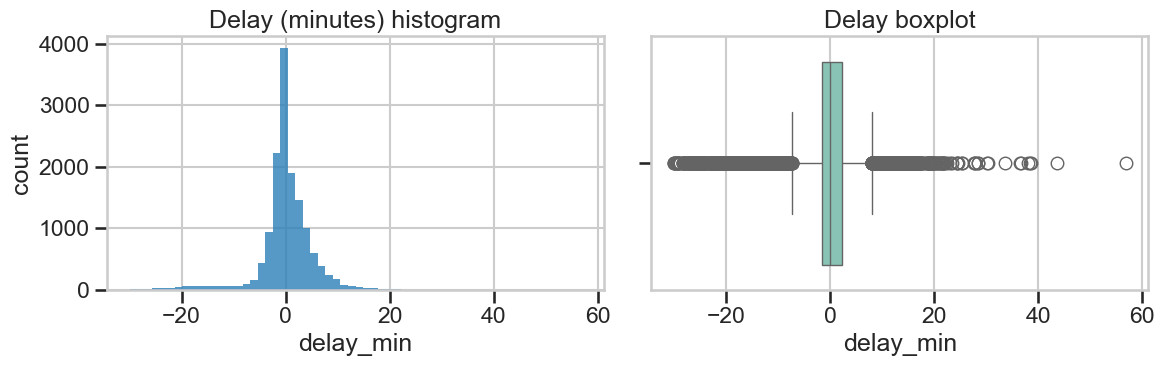

count    14587.000000
mean         0.063313
std          5.453552
min        -30.000000
25%         -1.570000
50%          0.000000
75%          2.290000
max         56.820000
Name: delay_min, dtype: float64
Absolute delay describe:
count    14587.000000
mean         3.255977
std          4.375286
min          0.000000
25%          0.680000
50%          1.880000
75%          3.950000
max         56.820000
Name: delay_abs, dtype: float64


In [348]:
# Delay distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_focus['delay_min'], bins=60, color='#2c7fb8', alpha=0.8)
axes[0].set_title('Delay (minutes) histogram')
axes[0].set_xlabel('delay_min')
axes[0].set_ylabel('count')

sns.boxplot(x='delay_min', data=df_focus, ax=axes[1], color='#7fcdbb')
axes[1].set_title('Delay boxplot')
plt.tight_layout()
plt.show()

print(df_focus['delay_min'].describe())

print('Absolute delay describe:')
print(df_focus['delay_abs'].describe())


            count      mean  median       std    min    max
is_raining                                                 
dry          7575 -0.013077     0.0  5.434307 -29.83  43.55
rain         7012  0.145837     0.0  5.473455 -30.00  56.82


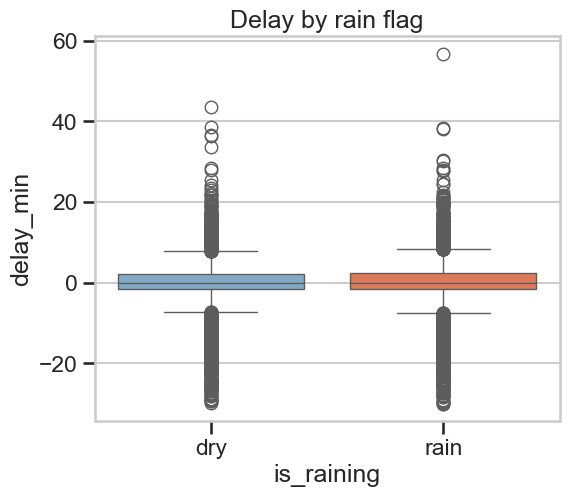

In [349]:
# Rain vs. dry comparison
rain_stats = (
    df_focus.groupby('is_raining')['delay_min']
      .agg(['count','mean','median','std','min','max'])
      .rename(index={0:'dry',1:'rain'})
)
print(rain_stats)

plt.figure(figsize=(6,5))
sns.boxplot(data=df_focus, x='is_raining', y='delay_min', hue='is_raining',
            palette=['#74add1','#f46d43'], legend=False)
plt.xticks([0,1], ['dry','rain'])
plt.title('Delay by rain flag')
plt.show()


In [350]:
# Rain vs non-rain delay summary (counts, mean/median, late rates)
rain_summary = (
    df_focus
    .assign(is_late_2m = df_focus['delay_min'] > 2,
            is_late_5m = df_focus['delay_min'] > 5)
    .groupby('is_raining')
    .agg(
        records=('delay_min','count'),
        mean_delay=('delay_min','mean'),
        median_delay=('delay_min','median'),
        p90_delay=('delay_min', lambda x: x.quantile(0.9)),
        late_2m_rate=('is_late_2m','mean'),
        late_5m_rate=('is_late_5m','mean')
    )
)

rain_summary.index = rain_summary.index.map({0:'dry', 1:'rain'})
print(rain_summary)


            records  mean_delay  median_delay  p90_delay  late_2m_rate  \
is_raining                                                               
dry            7575   -0.013077           0.0       5.13      0.264422   
rain           7012    0.145837           0.0       5.37      0.281517   

            late_5m_rate  
is_raining                
dry             0.102838  
rain            0.111380  


In [351]:
# Max precipitation value and count of records at that level
max_precip = df_focus['precipitation_mm'].max()
max_precip_count = (df_focus['precipitation_mm'] == max_precip).sum()
print(f"Max precipitation_mm: {max_precip}")
print(f"Records at max precipitation: {max_precip_count}")


Max precipitation_mm: 2.7
Records at max precipitation: 233


In [352]:
# Rain/snow category counts and delay stats
# precipitation_mm == 0 → 'dry'; otherwise map WMO code
rain_map = {
    51: 'drizzle', 53: 'drizzle', 55: 'drizzle',
    61: 'rain_light', 63: 'rain_moderate', 65: 'rain_heavy',
    66: 'freezing_rain', 67: 'freezing_rain',
    80: 'shower', 81: 'shower', 82: 'shower',
    95: 'thunderstorm', 96: 'thunderstorm', 99: 'thunderstorm',
    # Snow codes
    71: 'snow_light', 73: 'snow_moderate', 75: 'snow_heavy', 77: 'snow_grains',
    85: 'snow_shower_light', 86: 'snow_shower_heavy',
}

weather_map = df_focus['weather_code'].map(rain_map).fillna('other')
cat = weather_map.where(df_focus['precipitation_mm'] > 0, 'dry')

gb = df_focus.assign(category=cat).groupby('category')
summary = gb['delay_min'].agg(records='count', mean_delay='mean', median_delay='median')
summary['mean_precip_mm'] = gb['precipitation_mm'].mean()
summary = summary.sort_values('records', ascending=False)

total = summary['records'].sum()
summary['pct'] = (summary['records'] / total * 100).round(1)
summary = summary[['records','pct','mean_precip_mm','mean_delay','median_delay']]
summary['mean_precip_mm'] = summary['mean_precip_mm'].round(2)
summary['mean_delay'] = summary['mean_delay'].round(2)
summary['median_delay'] = summary['median_delay'].round(2)
print(summary)


               records   pct  mean_precip_mm  mean_delay  median_delay
category                                                              
drizzle           6198  42.5            0.51        0.10          0.00
dry               6078  41.7            0.00       -0.06          0.00
snow_light        1133   7.8            0.92        0.34          0.00
rain_moderate      414   2.8            2.66        0.72          0.31
rain_light         400   2.7            2.05        0.33          0.00
snow_moderate      364   2.5            1.10       -0.29          0.00


count    14587.000000
mean        -1.556849
std          1.669927
min         -5.000000
25%         -2.666667
50%         -1.650000
75%         -0.733333
max          5.000000
Name: snapshot_pred_diff_min, dtype: float64
Share within ±5 min: 100.0%


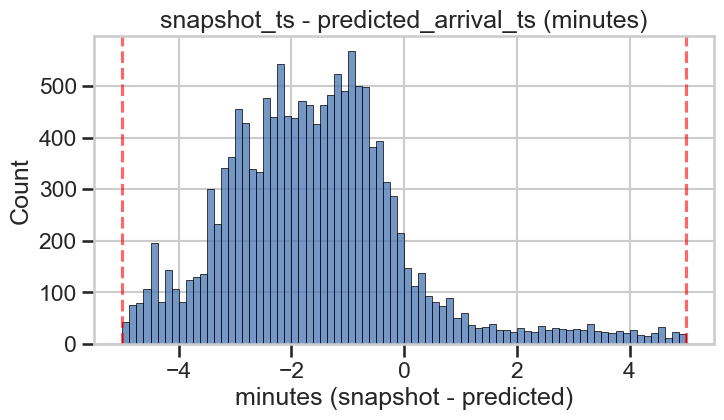

In [353]:
# Snapshot vs predicted arrival sanity check
# Expect snapshot_ts ≈ predicted_arrival_ts when bus is at stop.
df_focus['snapshot_pred_diff_min'] = (df_focus['snapshot_ts'] - df_focus['predicted_arrival_ts']) / 60
print(df_focus['snapshot_pred_diff_min'].describe())

within5 = (df_focus['snapshot_pred_diff_min'].abs() <= 5).mean()*100
print(f"Share within ±5 min: {within5:.1f}%")

plt.figure(figsize=(8,4))
sns.histplot(df_focus['snapshot_pred_diff_min'], bins=80, color='#4575b4')
plt.axvline(5, color='red', linestyle='--', alpha=0.6)
plt.axvline(-5, color='red', linestyle='--', alpha=0.6)
plt.title('snapshot_ts - predicted_arrival_ts (minutes)')
plt.xlabel('minutes (snapshot - predicted)')
plt.show()

In [354]:
# Optional: single-route deep dive
if RUN_ROUTE:
    target_route = str(ROUTE_TARGET)
    r = df_focus[df_focus['route_short_name'] == target_route].copy()
    if len(r) == 0:
        print(f"Route {target_route} not found in current df_focus")
    else:
        print(f"Route {target_route} records: {len(r)}")
        print(f"Mean delay: {r['delay_min'].mean():.2f} min")
        print()

        print("=== By Hour of Day ===")
        print(r.groupby('hour_of_day')['delay_min'].agg(['mean','count']).round(2))

        print("=== By Day of Week ===")
        day_labels = {0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'}
        r['day_label'] = r['day_of_week'].map(day_labels)
        print(r.groupby('day_label')['delay_min'].agg(['mean','count']).round(2))

        print("=== By Rain ===")
        print(r.groupby('is_raining')['delay_min'].agg(['mean','median','count']).round(2))

        print("=== By Peak Hour ===")
        print(r.groupby('is_peak_hour')['delay_min'].agg(['mean','median','count']).round(2))

        print("=== By Weekend ===")
        print(r.groupby('is_weekend')['delay_min'].agg(['mean','median','count']).round(2))
else:
    print('RUN_ROUTE = False; skipping route deep dive')


RUN_ROUTE = False; skipping route deep dive


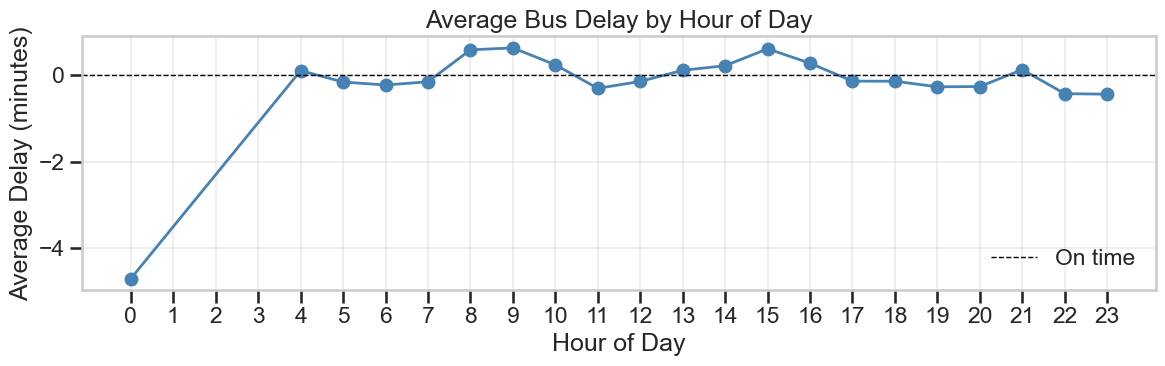

In [355]:
# Time Feature Analysis

# Figure 1: Average delay by hour of day
plt.figure(figsize=(12, 4))
hourly_delay = df_focus.groupby('hour_of_day')['delay_min'].mean()
plt.plot(hourly_delay.index, hourly_delay.values, 'o-', color='steelblue', linewidth=2)
plt.axhline(0, color='black', linestyle='--', linewidth=1, label='On time')
plt.title('Average Bus Delay by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Delay (minutes)')
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


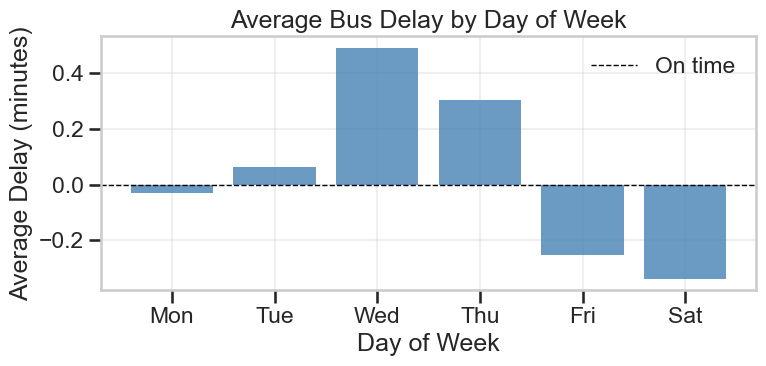

In [356]:
# Figure 2: Average delay by day of week
plt.figure(figsize=(8, 4))
day_labels = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}
daily_delay = df_focus.groupby('day_of_week')['delay_min'].mean()
daily_delay.index = [day_labels[d] for d in daily_delay.index]
plt.bar(daily_delay.index, daily_delay.values, color='steelblue', alpha=0.8)
plt.axhline(0, color='black', linestyle='--', linewidth=1, label='On time')
plt.title('Average Bus Delay by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Delay (minutes)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


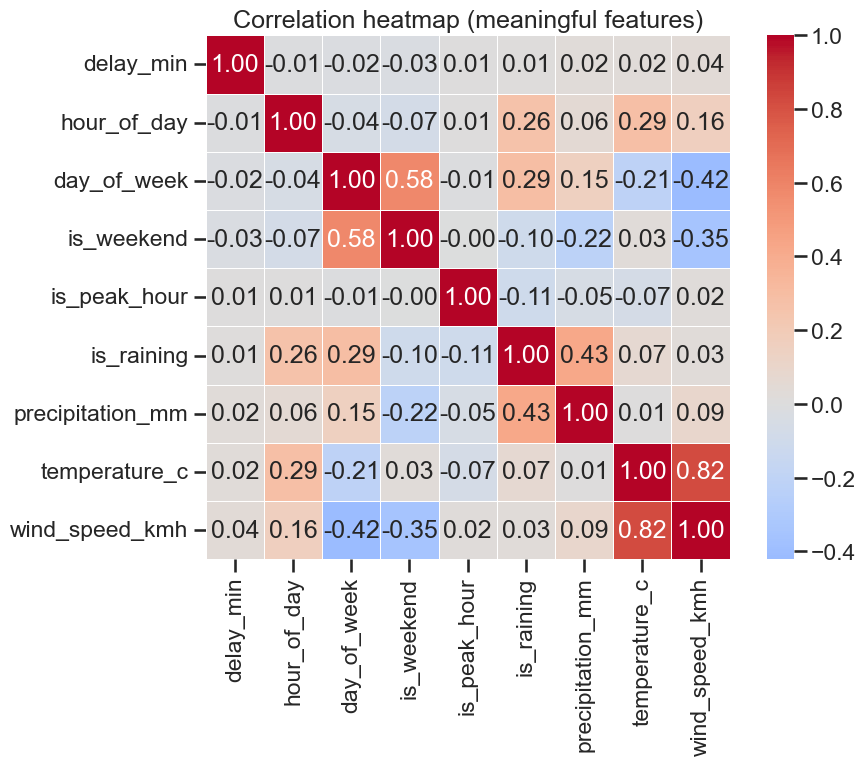

=== Correlation with delay_min ===
delay_min           1.000000
wind_speed_kmh      0.039218
temperature_c       0.024564
precipitation_mm    0.024060
is_raining          0.014559
is_peak_hour        0.009717
hour_of_day        -0.008796
day_of_week        -0.018293
is_weekend         -0.025831
Name: delay_min, dtype: float64


In [357]:
# Correlation heatmap — meaningful features only
feature_cols = [
    'delay_min',
    'hour_of_day', 'day_of_week', 'is_weekend', 'is_peak_hour',
    'is_raining', 'precipitation_mm', 'temperature_c', 'wind_speed_kmh'
]
corr = df_focus[feature_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation heatmap (meaningful features)')
plt.tight_layout()
plt.show()

# Print correlation with target variable specifically
print("=== Correlation with delay_min ===")
print(corr['delay_min'].sort_values(ascending=False))

## Notes / To-do
- Consider adding engineered features: route encoding, rain×peak interaction, rolling averages by route/hour.
- Re-run this notebook after any pipeline change to confirm distributions and sanity checks remain stable.